1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random

2. Device Configuration and Seed Initialization

In [2]:
# --- Device Configuration & Environment Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Setting strict random seeds to guarantee experiment reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

3. Load CIFAR-10 Dataset

In [3]:
 # --- Data Preprocessing Pipeline ---
# Standard normalization parameters for CIFAR-10 data validation streams
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# --- Dataset Download & Extraction ---
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# --- Data Pipeline Initialization (Dataloaders) ---
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

4. Improved CNN

In [4]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        # The single minor architectural improvement layer authorized by instructions
        self.bn1 = nn.BatchNorm2d(32) 

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Convolutional Block 1 (With active Batch Normalization)
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # Convolutional Block 2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        # Convolutional Block 3
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        # Convolutional Block 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)

        # Flattening representation vector for fully-connected classification layers
        x = x.view(x.size(0), -1)

        # Classification Layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

5. Optimization Setup

In [5]:
model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

6. Model Core Training Protocol

In [6]:
def train(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0
    gradient_norms = {}

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Monitoring gradient magnitudes across layers via param.grad attributes
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                if name not in gradient_norms:
                    gradient_norms[name] = []
                gradient_norms[name].append(grad_norm)

        optimizer.step()
        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms

7. Validation/Testing Routine

In [7]:
def test(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy

8. Primary Optimization Loop Orchestration

Epoch 1/15
Train Loss: 1.4360 | Train Accuracy: 47.29%
Test Loss: 1.0700 | Test Accuracy: 62.88%
--------------------------------------------------
Epoch 2/15
Train Loss: 0.9241 | Train Accuracy: 67.62%
Test Loss: 0.8736 | Test Accuracy: 69.65%
--------------------------------------------------
Epoch 3/15
Train Loss: 0.7219 | Train Accuracy: 74.92%
Test Loss: 0.7644 | Test Accuracy: 73.60%
--------------------------------------------------
Epoch 4/15
Train Loss: 0.5853 | Train Accuracy: 79.69%
Test Loss: 0.7141 | Test Accuracy: 75.62%
--------------------------------------------------
Epoch 5/15
Train Loss: 0.4797 | Train Accuracy: 83.17%
Test Loss: 0.7051 | Test Accuracy: 77.53%
--------------------------------------------------
Epoch 6/15
Train Loss: 0.3880 | Train Accuracy: 86.46%
Test Loss: 0.7259 | Test Accuracy: 77.17%
--------------------------------------------------
Epoch 7/15
Train Loss: 0.2976 | Train Accuracy: 89.59%
Test Loss: 0.7471 | Test Accuracy: 77.45%
---------------

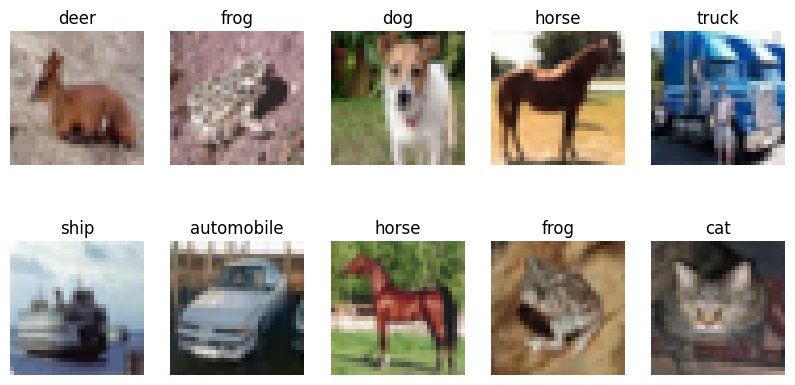

In [8]:
num_epochs = 15

train_losses, test_losses = [], []
train_accs, test_accs = [], []
epoch_gradient_norms = {}

for epoch in range(num_epochs):
    train_loss, train_acc, grad_norms = train(model, train_loader)
    test_loss, test_acc = test(model, test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Aggregating batch gradient tracking data into epoch-level mean statistics
    for name, values in grad_norms.items():
        if name not in epoch_gradient_norms:
            epoch_gradient_norms[name] = []
        epoch_gradient_norms[name].append(np.mean(values))

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")
    print("-" * 50)

# --- Structural Verification Visualizations ---
classes = train_dataset.classes
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # Denormalizing pixel configurations
    img = img.permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.show()

9. QUANTITATIVE REPORT VISUALIZATIONS

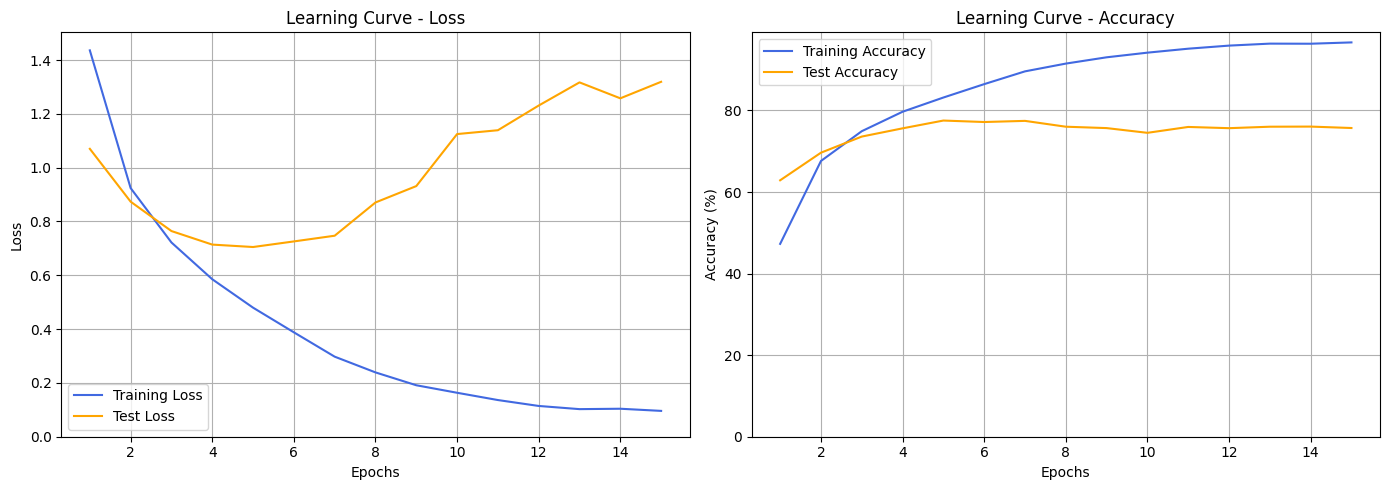

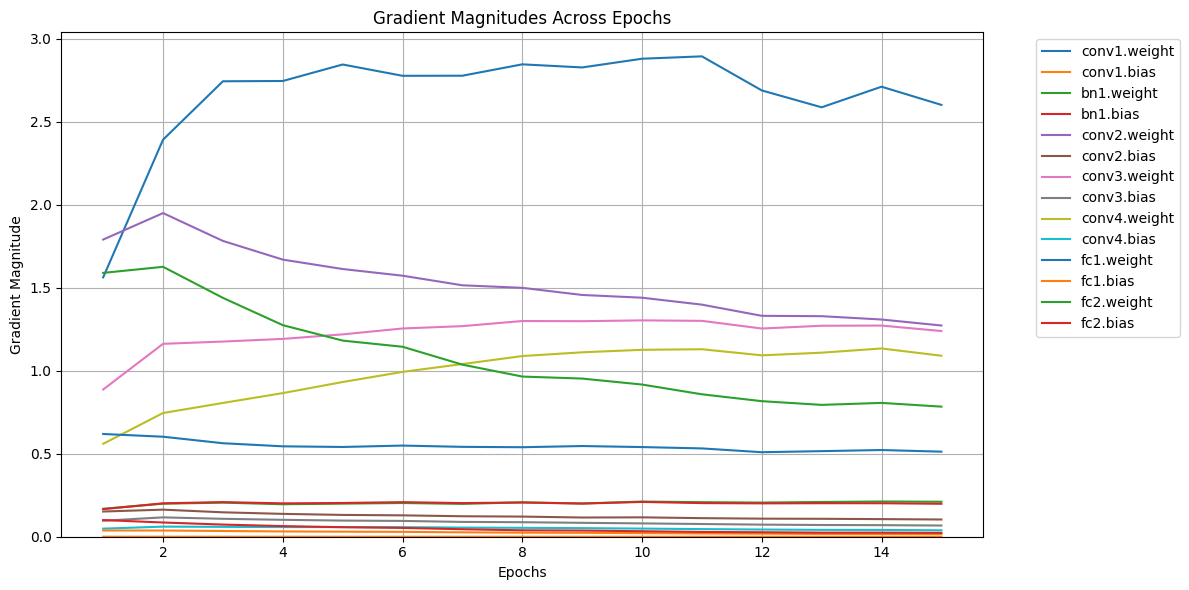

In [9]:
epochs_range = range(1, num_epochs + 1)

# Plot Series 1: Quantitative Learning Curves (Loss & Accuracy Trajectories)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='royalblue')
plt.plot(epochs_range, test_losses, label='Test Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Training Accuracy', color='royalblue')
plt.plot(epochs_range, test_accs, label='Test Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Learning Curve - Accuracy')
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot Series 2: Backpropagation Evaluation (Layer-wise Gradient Magnitudes)
plt.figure(figsize=(12, 6))
for name, layer_norms in epoch_gradient_norms.items():
    plt.plot(epochs_range, layer_norms, label=name)
plt.xlabel('Epochs')
plt.ylabel('Gradient Magnitude')
plt.title('Gradient Magnitudes Across Epochs')
plt.ylim(bottom=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()